# Creating a random circuit
The code below defines a function that creates a random circuit given the number of qubits and the circuit depth.

In [1]:
import random
from qiskit import QuantumCircuit
from quantum_optimiser.multimetric import rewrite
from quantum_optimiser import integration
import pyzx 

%load_ext autoreload
%autoreload 2
    

one_qubit_gates = ["h", "s", "sdg", "t", "tdg", "x", "z"]
two_qubit_gates = ["cx","cz",]

def random_circuit_generator(max_qubits, max_depth):
    qubits = random.randint(2, max_qubits)
    depth = random.randint(2, max_depth)
    qc = QuantumCircuit(qubits)

          
    for i in range(depth):
        if random.random() < 0.6:
            q = random.randrange(qubits)
            gate = random.choice(one_qubit_gates)
            getattr(qc, gate)(q)
        else:
            q1, q2 = random.sample(range(qubits), 2)
            gate = random.choice(two_qubit_gates)
            getattr(qc, gate)(q1, q2)

    return qc


qc = random_circuit_generator(100,100)
qc.draw("mpl")
diagram = integration.qiskit_to_pyzx(qc)
pyzx.draw(diagram, labels = "true")

for i in range (0,200):
    print(i)
    print(rewrite.get_applicable_rules(diagram,i))

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen 

0
['lcomp', 'pivot']
1
['lcomp', 'pivot']
2
['lcomp', 'pivot']
3
['lcomp', 'pivot']
4
['lcomp', 'pivot']
5
['lcomp', 'pivot']
6
['lcomp', 'pivot']
7
['lcomp', 'pivot']
8
['lcomp', 'pivot']
9
['lcomp', 'pivot']
10
['lcomp', 'pivot']
11
['lcomp', 'pivot']
12
['lcomp', 'pivot']
13
['lcomp', 'pivot']
14
['lcomp', 'pivot']
15
['lcomp', 'pivot']
16
['lcomp', 'pivot']
17
['lcomp', 'pivot']
18
['lcomp', 'pivot']
19
['lcomp', 'pivot']
20
['lcomp', 'pivot']
21
['lcomp', 'pivot']
22
['lcomp', 'pivot']
23
['lcomp', 'pivot']
24
['lcomp', 'pivot']
25
['lcomp', 'pivot']
26
['lcomp', 'pivot']
27
['lcomp', 'pivot']
28
['lcomp', 'pivot']
29
['lcomp', 'pivot']
30
['lcomp', 'pivot']
31
['lcomp', 'pivot']
32
['lcomp', 'pivot']
33
['lcomp', 'pivot']
34
['lcomp', 'pivot']
35
['lcomp', 'pivot']
36
['color_change', 'lcomp', 'pivot']
37
['color_change', 'lcomp', 'pivot']
38
['color_change', 'lcomp', 'pivot']
39
['color_change', 'strong_comp', 'lcomp', 'pivot']
40
['color_change', 'strong_comp', 'lcomp', 'pivot'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0
['lcomp', 'pivot']
1
['lcomp', 'pivot']
2
['lcomp', 'pivot']
3
['lcomp', 'pivot']
4
['lcomp', 'pivot']
5
['lcomp', 'pivot']
6
['lcomp', 'pivot']
7
['lcomp', 'pivot']
8
['lcomp', 'pivot']
9
['lcomp', 'pivot']
10
['lcomp', 'pivot']
11
['lcomp', 'pivot']
12
['lcomp', 'pivot']
13
['lcomp', 'pivot']
14
['lcomp', 'pivot']
15
['lcomp', 'pivot']
16
['lcomp', 'pivot']
17
['lcomp', 'pivot']
18
['lcomp', 'pivot']
19
['lcomp', 'pivot']
20
['lcomp', 'pivot']
21
['lcomp', 'pivot']
22
['lcomp', 'pivot']
23
['lcomp', 'pivot']
24
['lcomp', 'pivot']
25
['lcomp', 'pivot']
26
['lcomp', 'pivot']
27
['lcomp', 'pivot']
28
['lcomp', 'pivot']
29
['lcomp', 'pivot']
30
['lcomp', 'pivot']
31
['lcomp', 'pivot']
32
['lcomp', 'pivot']
33
['lcomp', 'pivot']
34
['lcomp', 'pivot']
35
['lcomp', 'pivot']
36
['color_change', 'lcomp', 'pivot']
37
['color_change', 'lcomp', 'pivot']
38
['color_change', 'lcomp', 'pivot']
39
['color_change', 'strong_comp', 'lcomp', 'pivot']
40
['color_change', 'strong_comp', 'lcomp', 'pivot'

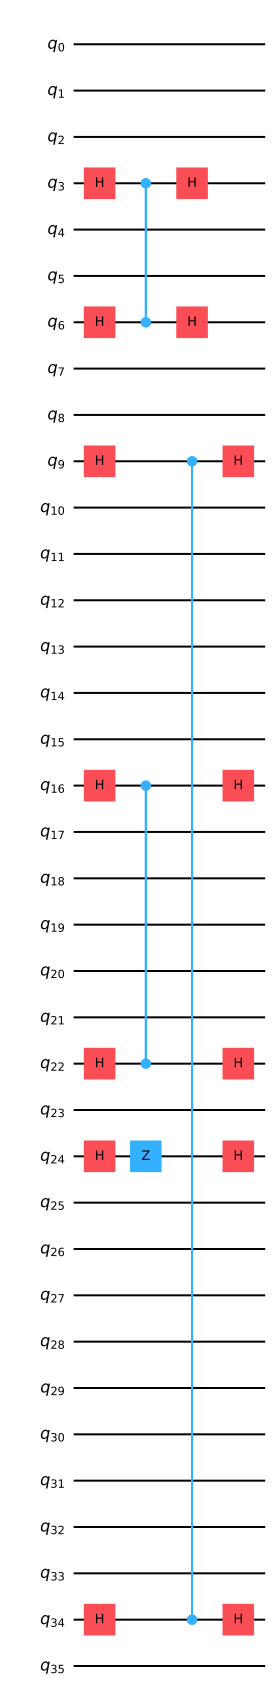

In [2]:
%load_ext autoreload
%autoreload 2

from qiskit.circuit.random import random_circuit
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import simulated_annealing
from quantum_optimiser.multimetric import rewrite

from qiskit import transpile
import pyzx
from IPython.display import display





best_circuit, best_diagram, best_cost, _ = simulated_annealing.simulated_annealing_zx(
                circuit=qc,
                cost_function=loss.log_weighted_loss,
                get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=1000,
                max_no_improvement=1000,
            )

pyzx.draw(diagram, labels = "true")
pyzx.draw(best_diagram, labels = "true")
for i in range (0,200):
    print(i)
    print(rewrite.get_applicable_rules(best_diagram,i))
    
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

# Evaluating the optimiser
The code below generates 10 random circuits of the same size, and prints out the average decrease in each cost function as well as the average decrease of each metric

In [4]:
import numpy as np

def get_metrics(circuit):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit),
        "gates": metrics.circuit_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit)
    before_L = loss_fn(circuit)
    optimised_circuit, optimised_diagram, optimised_cost, _ =  simulated_annealing.simulated_annealing_zx(
                circuit=circuit,
                cost_function=loss_fn,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=500,
                max_no_improvement=50,   
            )
    after_m = get_metrics(optimised_circuit)
    after_L = optimised_cost

    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate(n_circuits=10, qubits=100, depth=100):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }

    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}
    
    circuits = [random_circuit_generator(qubits, depth) for i in range(n_circuits)]
    for qc in circuits:
        for name,L in functions.items():
            dL, dm = evaluate_once(qc, L)
            cost_deltas[name].append(dL)
            metric_deltas[name].append(dm)

    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")

    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")

        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():  
            print(f"  Avg {k} decrease: {v:.4f}")
        print()


evaluate()


KeyboardInterrupt


KeyboardInterrupt



In [5]:
from joblib import Parallel, delayed
import numpy as np
from quantum_optimiser.hardware_aware import hardware_map
from quantum_optimiser.hardware_aware import hardwares


def get_metrics(circuit):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit),
        "gates": metrics.circuit_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit)
    before_L = loss_fn(circuit)
    optimised_circuit, optimised_diagram, optimised_cost, _ = simulated_annealing.simulated_annealing_zx(
        circuit=circuit,
        cost_function=loss_fn,
        get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
        initial_temp=100.0,
        cooling_rate=0.95,
        max_iterations=500,
        max_no_improvement=50,
        hardware=hardwares.sherbrooke
    )
    after_m = get_metrics(optimised_circuit)
    after_L = optimised_cost
    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate_once_wrapper(circuit, name):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }
    dL, dm = evaluate_once(circuit, functions[name])
    return name, dL, dm

def evaluate(n_circuits=10, depth=100,hardware=None):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }
    qubits = hardware.qubits  # match the hardware map
    circuits = [random_circuit_generator(qubits, depth) for _ in range(n_circuits)]
    
    tasks = [
        (qc, name)
        for qc in circuits
        for name in functions
    ]
    
    results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(evaluate_once_wrapper)(qc, name)
        for qc, name in tasks
    )
    
    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}
    
    for name, dL, dm in results:
        cost_deltas[name].append(dL)
        metric_deltas[name].append(dm)
    
    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")
    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")
        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():
            print(f"  Avg {k} decrease: {v:.4f}")
        print()

evaluate(hardware=hardwares.sherbrooke)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   30.2s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   42.9s
[Parallel(n_jobs=-1)]: Done  22 out of  40 | elapsed:   51.0s remaining:   41.7s
[Parallel(n_jobs=-1)]: Done  27 out of  40 | elapsed:  1.1min remaining:   30.8s
[Parallel(n_jobs=-1)]: Done  32 out of  40 | elapsed:  1.3min remaining:   19.5s
[Parallel(n_jobs=-1)]: Done  37 out of  40 | elapsed:  1.4min remaining:    6.9s



Benchmark over 10 circuits | qubits=127 depth=100

naive
Avg cost decrease: 0.0000
  Avg qubits decrease: -20.6000
  Avg two_qubit decrease: -354.4000
  Avg gates decrease: -354.4000
  Avg depth decrease: -188.9000
  Avg t decrease: 0.0000

informed
Avg cost decrease: 0.0000
  Avg qubits decrease: -20.6000
  Avg two_qubit decrease: -354.4000
  Avg gates decrease: -354.4000
  Avg depth decrease: -188.9000
  Avg t decrease: 0.0000

log_weighted
Avg cost decrease: 0.0000
  Avg qubits decrease: -20.6000
  Avg two_qubit decrease: -354.4000
  Avg gates decrease: -354.4000
  Avg depth decrease: -188.9000
  Avg t decrease: 0.0000

quadratic
Avg cost decrease: 0.0000
  Avg qubits decrease: -20.6000
  Avg two_qubit decrease: -354.4000
  Avg gates decrease: -354.4000
  Avg depth decrease: -188.9000
  Avg t decrease: 0.0000



[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:  1.5min finished
